In [4]:
# Diogo Souza - Jul 14 2025
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import h5py
from sklearn.decomposition import PCA
from getdist import MCSamples, plots
from scipy.stats import norm
from numpy import linalg as la

from cobaya.yaml import yaml_load
from cobaya.model import get_model
import sys, os
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model

plt.rcParams['figure.figsize'] = (3.5, 2.5)

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.size'] = 15

colors1 = [
    "#1b5f6f",  # dark teal
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#882255",  # wine
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#999999",  # grey
    "#117733",  # dark green
]

camb_path = os.path.dirname(camb.__file__)
cocoa_path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa' # Change for your path 
path = f'{cocoa_path}/cocoa_photoz'
print('Using CAMB %s installed at %s'%(camb.__version__,camb_path))

Using CAMB 1.6.1 installed at /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb


# Survey class and methods

In [7]:
class SURVEY:
    def __init__(self,survey,use_r=None):
        self.survey = survey
        self.use_r = use_r

    # Global parameters
    def nz_params(self):
        if self.survey == 'des':
            Nz = 299 #len(z)
            Nt = 4
        elif self.survey == 'roman':   
            Nz = 46 #len(z)
            Nt = 9
        return Nz,Nt

    # Auxiliary functions
    def get_nzs(self):
        Nz,Nt = self.nz_params()
        if self.survey == 'des':
            nz = f'{path}/roman_nz_realizations/Fisher_matrix/Tz_realizations_WZ_bq_pile3_0d01.npy' # shared by Boyan Yin
            nz = np.load(nz)             ## shape = (10095, 4, 300) = (Ns, Nt, Nz) = (# of simulations, # of tomo bins, # of redshift)
            nz = nz[:,:,1:]              ## shape = (10095, 4, 299) | (first :) => all 10095 simulations, (second :) => all 4 tomo bins, (third ,1:) => all redshift bins except the first where nz is 0.0.
            Ns = np.shape(nz)[0]         ## Number of simulations: 10095
            nz = nz.reshape(Ns, Nt * Nz) ## shape = (10095, 1196) = (Ns, Nt*Nz)
            min_z   = 0.01
            max_z   = 3
            delta_z = (max_z - min_z) / Nz
            zbins   = np.arange(min_z,max_z+delta_z,delta_z)
            z  = zbins[:-1]+(zbins[1]-zbins[0])/2.
            return z, nz

        elif self.survey == 'roman':
            sc = 'sc1bd4'
            nz = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r') # shared by Boyan Yin
            z = np.array(nz['zbinsc'])
            return z, nz

    def roman_nbar(self):    
        nbar = f'{path}/n_nbar_ndiff_covndiff/nbar_sc1b_d4.nz'
        return nbar

    def cov_of_ndiff(self):
        Nz,Nt = self.nz_params()
        z,nz = self.get_nzs()

        if self.survey == 'roman':
            # Never use r=10^6 on login node.
            if self.use_r is not None:
                #np.random.seed(42)
                #sims_indexes = np.random.randint(1, 10**6 + 1, size=self.use_r)
                # tot = len(sims_indexes)
                sims_indexes = self.use_r

                rows = []
                print(f"Total # of realizations r = {self.use_r}\nNormalizing nz for r:")
                for jj, j in enumerate(sims_indexes):
                    row = []
                    for i in range(Nt):
                        norm = np.trapz(y=nz[f'bin{i}'][j], x=z)
                        normalized = nz[f'bin{i}'][j] / norm
                        row.append(normalized)
                    #row shape after appending all bins: (Nt,Nz)
                    print(jj, end=' ')
                    rows.append(np.hstack(row))
                #rows shape after appending all realizations: (tot,Nt*Nz)
                nz = np.vstack(rows) # (tot,Nt*Nz)
                nbar = np.mean(nz,axis=0)
                ndiff = nz - nbar
                Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff / sample size - 1
            else:
                # Use Cn from all 10^6
                Cn = np.load(f'{path}/n_nbar_ndiff_covndiff/cov_ndiff_sc1b_d4.npy') #TODO: path changed    
                ndiff = None # Because we can't load (414,1M) data here
        elif self.survey == 'des':
            ### nzs for DES already are normalized
            ### set parameter below to True if you want to check
            check_des_nz_normalization = False
            if check_des_nz_normalization:
                rows = []
                for j in range(10095):
                    row = []
                    for i in range(Nt):
                        start, end = Nz*i, Nz*(i+1)
                        norm = np.trapz(y=nz[j,start:end], x=z)
                        normalized = nz[j,start:end] / norm
                        row.append(normalized)
                    rows.append(np.hstack(row))
                nz = np.vstack(rows)

            nbar = np.mean(nz,axis=0)
            ndiff = nz - nbar
            Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff / sample size - 1
        self.Cn = Cn
        self.ndiff = ndiff    
        return self.Cn, self.ndiff
    
    # Unweighted PCA    
    def pcs(self,method='eig'):
        Nz,Nt = self.nz_params()
        Nd = Nz*Nt
        if method == 'eig':
            eig_vals, eig_vecs = np.linalg.eig(self.Cn)
            eigvals, eigvecs = np.linalg.eig(self.Cn)
        elif method == 'eigh':
            eigvals, eigvecs = np.linalg.eigh(self.Cn)
        elif method == 'svd':    
            U, S, VT = np.linalg.svd(self.Cn)
            eigvecs, eigvals = U,S
        elif method == 'sklearn':
            pca = PCA()
            pca.fit(self.Cn)
            eigvecs, eigvals = pca.components_, pca.singular_values_
            explained_variance = pca.explained_variance_
            explained_variance_ratio = pca.explained_variance_ratio_
        ######
        if method != 'sklearn':
            eigvals = np.real(eigvals)
            eigvecs = np.real(eigvecs)
            idx     = np.argsort(eigvals)[::-1] # 1. Get indices to sort eigenvalues in descending order
            eigvals = eigvals[idx]              # 2. Sort eigenvalues (largest to smallest)
            eigvals = np.maximum(0,eigvals)     # 3. Clamp any small negative eigenvalues to 0 (often due to numerical errors)
            eigvecs = eigvecs[:, idx]           # 4. Reorder columns of eigenvectors to match sorted eigenvalues
            return eigvecs, eigvals
        elif method == 'sklearn':
            return eigvecs.T, eigvals, explained_variance,explained_variance_ratio
    
    def forward_pca(self, params_values,nbar_path,pcs_path,npcs_nz):
        nbar = np.genfromtxt(nbar_path)
        U = np.genfromtxt(pcs_path)[:,:npcs_nz]
        s = nbar[:,1:].shape
        z = nbar[:,0]
        # Model: n(z) = <n>(z) + α_1*PC_1(z) + α_2*PC_2(z) + ... + α_n*PC_n(z)
        if npcs_nz > 0:
            alphas = np.array([params_values.get("roman_alpha_"+str(i+1)) for i in range(npcs_nz)])
            correction = (alphas * U).sum(axis=1)
    
            nz_model = nbar[:,1:].T.flatten() + correction
            nz_model = nz_model.reshape(s[::-1]).T
            nz_model = np.column_stack((z,nz_model))
            return nz_model
        else:
            return nbar

    # Credit: Gary M. Bernstein
    def nearestPD(self,A):
        """Find the nearest positive-definite matrix to input
        A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
        credits [2].
        [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd
        [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
        matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
        """
        B = (A + A.T) / 2
        _, s, V = np.linalg.svd(B)
        H = np.dot(V.T, np.dot(np.diag(s), V))
        A2 = (B + H) / 2
        A3 = (A2 + A2.T) / 2
        if self.isPD(A3):
            return A3
        spacing = np.spacing(np.linalg.norm(A))
        I = np.eye(A.shape[0])
        k = 1
        while not self.isPD(A3):
            mineig = np.min(np.real(np.linalg.eigvals(A3)))
            A3 += I * (-mineig * k**2 + spacing)
            k += 1
        return A3

    def isPD(self,B):
        """Returns true when input is positive-definite, via Cholesky"""
        try:
            _ = np.linalg.cholesky(B)
            return True
        except np.linalg.LinAlgError:
            return False              
    
    def getModes(self,D, Cn, chisq_threshold=0.1):
        '''Calculate the compression matrix from n to u and the
        modes U that multiply each U.  
        Parameters:
        `D`:      The matrix J^T C_c^{-1} J, where C_c is the covariance
                matrix of the observables c, and J is the Jacobian dc/dn,
                shape=(N,N)
        `Cn`:     Covariance matrix of the n(z) parameter vector n, shape=(N,N)
        `chisq_threshold`:  Your desired upper bound for the mean error in chisq
                resulting from the compression.
        Returns:
        `X`:      The compression matrix, u = X @ n, shape=(nModes,N).  The
                covariance matrix of the u's will be the identity.
        `U`:      The decoding matrix, n' = U @ u, shape=(N,nModes)
        `dchisq`: The mean chisq shift generated by each mode, shape=(nModes)
        `resid`:  Mean amount of chisq shift caused by compression.

        You can safely use fewer than `nModes` of the returned X and U if you 
        think the discarded `dchisq` values are small enough.'''

        thr = 1e-25     # Dynamic range threshold for eigenvalues

        # Symmetrize and sqrt D
        D = 0.5*(D + D.T)
        Dval, Dvec = np.linalg.eigh(D)
        # Any negatives are numerical problems
        Dval = np.maximum(0., Dval)

        # And Cn
        Cnval, Cnvec = np.linalg.eigh(Cn)
        Cnval = np.maximum(0., Cnval)

        # Build the keystone matrix and its SVD
        M = np.einsum('i,ji,jk,k->ik',np.sqrt(Cnval), Cnvec, Dvec, np.sqrt(Dval))
        Um,s,Vmt = np.linalg.svd(M)

        # Sort SV's and throw away unwanted ones
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
                                            
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        Um = Um[:,keep]
        Vm = Vmt.T[:,keep]
        s = s[keep]

        # Build the encoder
        tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
        X = np.einsum('ij,i,ki->jk',Um, tmp, Cnvec)  # X is (M,N)
        # And the decoder
        tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
        U = np.einsum('ji,i,ik,k->jk',Dvec, tmp, Vm,s) # Vm s
        
        return X, U, s*s, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M
    
    ###############################
    ############ CoCoA ############
    ###############################
    

# Unweighted PCA

## Roman case  

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{46}],[\text{PC}^1_{47},\text{PC}^1_{48},\cdots,\text{PC}^1_{92}],6\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{413},\cdots,\text{PC}^1_{414}]\Big]$

In [8]:
roman_obj = SURVEY('roman',use_r=None)
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()
nbar_file = roman_obj.roman_nbar()

Cn, ndiff = roman_obj.cov_of_ndiff() # must call before pcs

eig_vecs, eig_vals = roman_obj.pcs('eig')
eih_vecs, eih_vals = roman_obj.pcs('eigh')
svd_vecs, svd_vals = roman_obj.pcs('svd')
# np.savetxt('U.txt',eih_vecs) # Jul 18 using on MCMC

skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = roman_obj.pcs('sklearn')

/tmp/ipykernel_1999912/3046020584.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

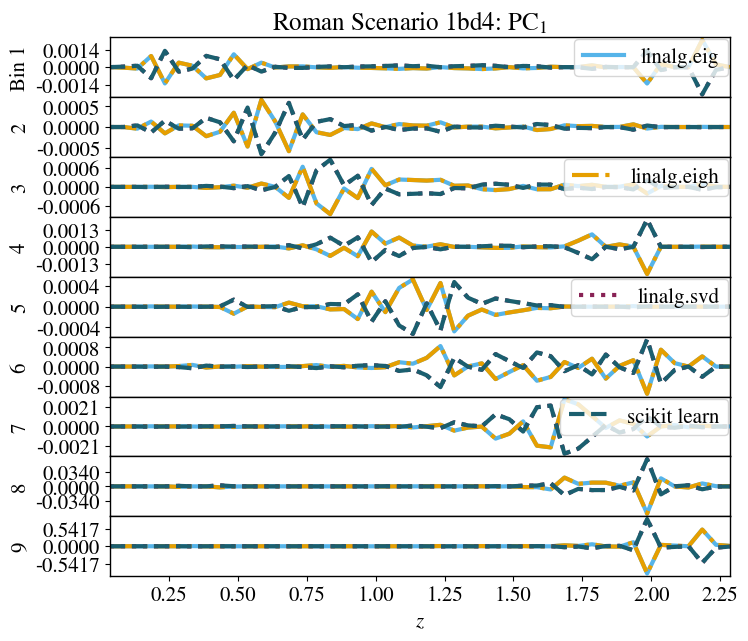

In [10]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2.5
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))
    ax.plot(z, eig_vecs[start:end, pci],c=colors[0],lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c=colors[1],lw=3, ls='-.', label='linalg.eigh' if k==2 else None)
    ax.plot(z, svd_vecs[start:end, pci],c=colors[2],lw=3, ls=':', label='linalg.svd' if k==4 else None)
    ax.plot(z, skl_vecs[start:end, pci],c=colors[3],lw=3, ls='--' , label='scikit learn' if k==6 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [1,3,5,7,8]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", y=0.92);

### Test 2 - Pick up the first three PCs and plot their slices across the tomographic bins

/tmp/ipykernel_1999912/94149385.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

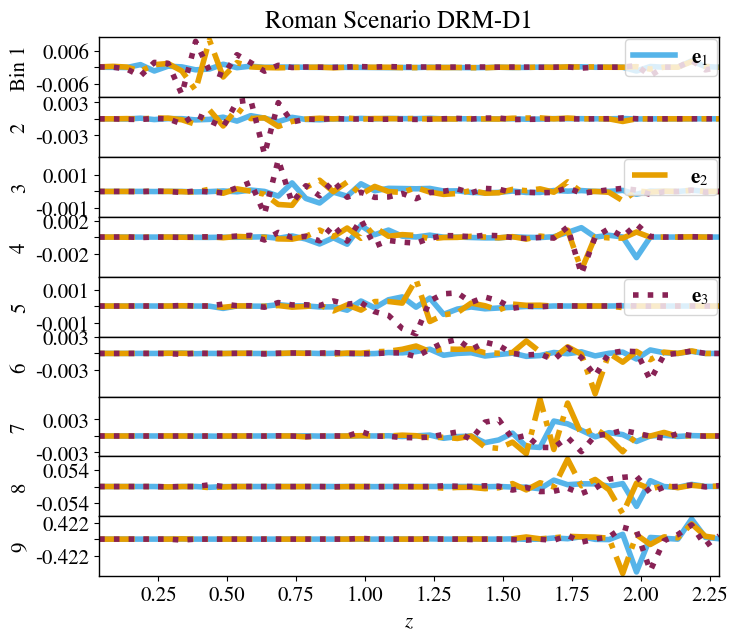

In [11]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = eig_vecs[start:end, pcis[0]]
    e2 = eig_vecs[start:end, pcis[1]]
    e3 = eig_vecs[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 2, 4]
    ax.plot(z, e1, c=colors[0], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls=':', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(9) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario DRM-D1", y=0.92);

### Test 3 - Plot the eigenvalues
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The eigenvalues/singular values are the same.

Text(0.5, 0.98, 'Roman Scenario 1bd4')

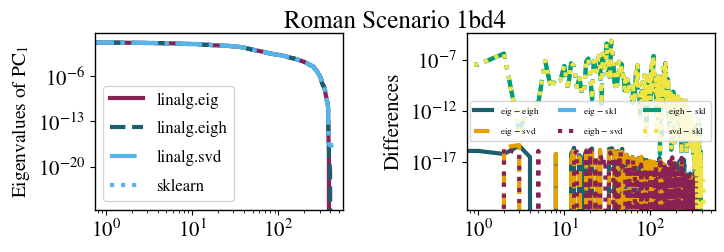

In [12]:
Ms = list(range(Nz*Nt))
colors=["#882255","#1b5f6f",'#56B4E9',"#56B4E9"]
fig, axes = plt.subplots(1, 2, figsize=(8, 2.3), sharex=True,gridspec_kw={'wspace':.5, 'hspace':1.0})

axes[0].plot(Ms,eig_vals ,c=colors[0],lw=3, ls='-' ,label='linalg.eig')
axes[0].plot(Ms,eih_vals,c=colors[1],lw=3, ls='--',label='linalg.eigh')
axes[0].plot(Ms,svd_vals ,c=colors[2],lw=3, ls='-.',label='linalg.svd')
axes[0].plot(Ms,skl_vals ,c=colors[3],lw=3, ls=':' ,label='sklearn')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(rf'Eigenvalues of PC$_1$',fontsize=14)
axes[0].legend(loc='best',fontsize=12)

axes[1].loglog(Ms,eig_vals-eih_vals,c=colors1[0],lw=3, ls='-' ,label=r'eig $-$ eigh')
axes[1].loglog(Ms,eig_vals-svd_vals, c=colors1[1],lw=3, ls='--',label=r'eig $-$ svd')
axes[1].loglog(Ms,eig_vals-skl_vals, c=colors1[2],lw=3, ls='-.',label=r'eig $-$ skl')

axes[1].loglog(Ms,eih_vals-svd_vals,c=colors1[3],lw=3, ls=':' ,label=r'eigh $-$ svd')
axes[1].loglog(Ms,eih_vals-skl_vals,c=colors1[4],lw=3, ls='-.',label=r'eigh $-$ skl')

axes[1].loglog(Ms,svd_vals-skl_vals, c=colors1[5],lw=3, ls=':',label=r'svd $-$ skl')
axes[1].legend(loc='center',fontsize=6.6,ncol=3)
axes[1].set_ylabel(rf'Differences')
fig.suptitle('Roman Scenario 1bd4')

### Test 4 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758).  
However, if we force $F=I$, then both methods possoes the same eigenvalue, while the eigenvector differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigenvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eigenvectors differ by a scaling factor of $\Lambda_n^{1/2}$:  
The decoding matrix (eq 19/20 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [13]:
D = np.identity(Cn.shape[0])

if not roman_obj.isPD(D):
    print('fixing cov')
    D=roman_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(D,Cn,chisq_threshold=0);

/tmp/ipykernel_1999912/924595602.py:225: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


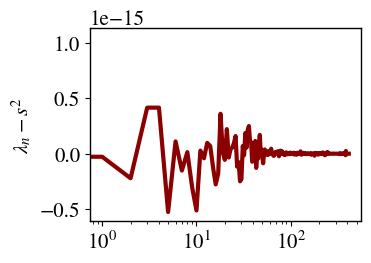

In [14]:
plt.plot(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.xscale('log')
plt.ylabel(r'$\lambda_n-s^2$');

/tmp/ipykernel_1999912/1062677139.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

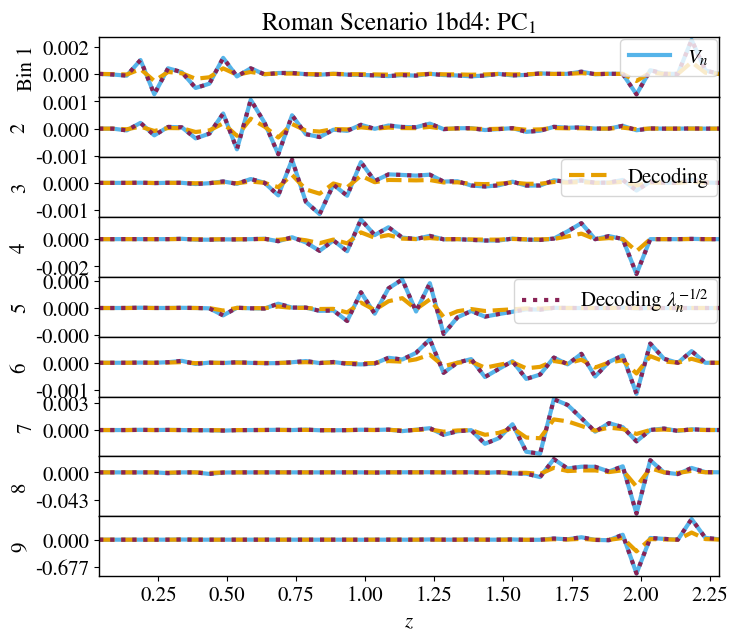

In [15]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix  = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0
ks = [0,2,4]
for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==ks[0] else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==ks[1] else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls=':', label=r'Decoding $\lambda_n^{-1/2}$' if k==ks[2] else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", y=0.92);

### Test 5 - sanity check 1  
The projection of the difference matrix, $\mathbf{\Delta}=\mathbf{n}-\bar{\mathbf{n}}$, onto the PC basis is $\alpha_i\equiv\langle\mathbf{\Delta},\mathbf{PC}_i\rangle$. Therefore, any realization of the redshift distribution $n^r(z)$ can be approximate by $n^r(z)\approx\hat{n}^r(z) \equiv \bar{n}(z)+\sum_{i=1}^{M\leq N}\alpha_i^r\mathbf{PC}_i(z)$ where $\alpha_i^r$ is the projection of the realization $\mathbf{\Delta}^r$ onto the PC basis, i.e. $\alpha_i^r\equiv\langle\mathbf{\Delta}^r,\mathbf{PC}_i\rangle$ or it can be seem as the $r$ th element of the sample $\alpha_i\equiv\langle\mathbf{\Delta},\mathbf{PC}_i\rangle$. The approximation becomes perfect, i.e. $\hat{n}^r(z)=n^r(z)~\forall~z$, when $M=N$, or if we tolerate a threshold $|\hat{n}^r(z)-n^r(z)|<\epsilon~\forall~z$ .

<Figure size 350x250 with 0 Axes>

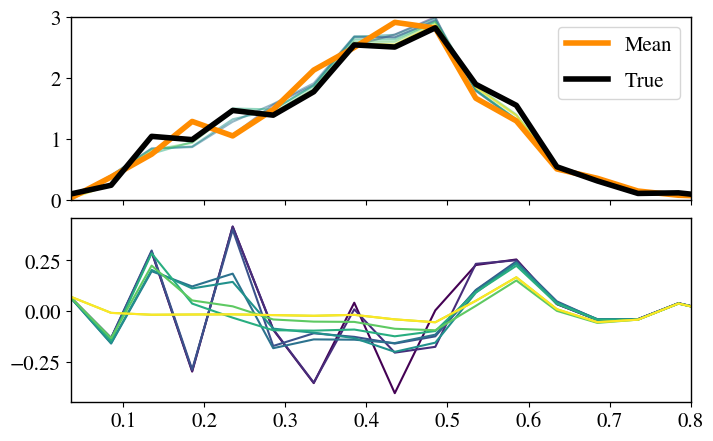

In [94]:
plt.figure()

params_values = {}
nbar_path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/nbar_sc1bd4.nz'
pcs_path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/U.txt'

n2 = np.genfromtxt('/gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/projects/roman_real/data/sc1bd4/nz_sc1bd4r0.nz')
nbar = np.genfromtxt(nbar_file)[:,1]
nbar2 = np.genfromtxt(nbar_path)[:,1]
norm_nbar = np.trapz(y=nbar,x=z)

nbar /= norm_nbar
n = nz['bin0'][0]
norm_n = np.trapz(y=n,x=z)
n /= norm_n

ndiff = n - nbar

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.1})

values_for_coloring = []
for i in range(9):
    values_for_coloring.append(i) # Assign a value for coloring each curve

cmap = plt.cm.viridis # You can choose other colormaps like 'plasma', 'inferno', 'magma', 'cividis', 'hot', etc.
norm = plt.Normalize(vmin=min(values_for_coloring), vmax=max(values_for_coloring))

npcs = [0,5,10,15,20,25,30,35,40]

for ii, npc in enumerate(npcs):
    nhat = np.zeros(46)
    for i in range(npc):
        alpi = np.dot(ndiff,eih_vecs[:46,i]) #eih_vals
        # print(f'      roman_alpha_{i+1}: {alpi}')
        params_values.update({f"roman_alpha_{i+1}": alpi})
        nhat += alpi*eih_vecs[:46,i]

    nhat = nbar + nhat

    nhat2 = roman_obj.forward_pca(params_values=params_values,nbar_path=nbar_path,pcs_path=pcs_path,npcs_nz=npc)
    color = cmap(norm(values_for_coloring[ii]))    
    axes[0].plot(z,nhat,color=color,ls='-',alpha=.5)
    axes[1].plot(z,n-nhat,color=color,ls='-')
    if npc==40:
        axes[0].plot(z,nbar,'darkorange',label='Mean',lw=4)
        axes[0].plot(z,n,'k',label='True',lw=4,ls='-')
        # axes[0].plot(z,nhat2[:,1],'k',ls=':')
        axes[0].set_xlim(np.min(z),.8);
        axes[0].set_ylim(0,3);
        axes[1].set_xlim(np.min(z),.8);
        # axes[1].set_ylim(0,3);
axes[0].legend(loc='best')
    # print(params_values)

In [19]:
# for i in range(60):
#     template = f"""  roman_alpha_{i+1}:
#     prior:
#       dist: norm
#       loc: 0.0
#       scale: 1.0
#     ref:
#       dist: norm
#       loc: 0.0
#       scale: 1.0
#     proposal: 1.0
#     latex: \\alpha_{{{i+1}}}"""
#     print(template)

### Test 6 - sanity check 2  
The likelihood is given by $L\propto\exp \left[-\frac{1}{2}\left(\mathbf{D}-\mathbf{M}\right)^\mathrm{T}\mathbf{C}^{-1}\left(\mathbf{D}-\mathbf{M}\right)\right]$ where $\mathbf{D}$ is the (observational or synthetic) data vector, $\mathbf{M}$ is the theoretical vector, and $\mathbf{C}$ is the covariance matrix.

In [22]:
# Load the yaml as Python dict
info_txt = f'{path}/yamls/roman_pca/modelvector.yaml'
with open(info_txt) as f:
    info = yaml_load(f)

# Adjust the paths for theory and likelihood codes
del info["theory"]["camb"]["path"]
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["path"] = f'{cocoa_path}/external_modules/data/roman_real/sc1bd4'
info["packages_path"] = camb_path

# Get the model in interactive mode using Cobaya `model` wrapper
model = get_model(info)


Classy could not be found in your system.
Here are some suggestions:

	 -Download the Class from class-code.net and install it
	  together with its wrapper classy (type 'make' instead of
	  'make class'
	 -If you know that Class is installed on your system
	  and yet classy could not be installed, try re-compiling
	  Class with just ''make'' instead of ''make class''
NOTICE: Even without classy you can still use EuclidEmulator2
        to emulate boost factors. You won't be able to compute
        full power spectra, though.
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False


#### Test 7.a - Simple Cobaya example:  
Cobaya `model` evaluation for Roman cosmic shear at fiducial cosmological parameters.

In [23]:
###########################################################
# [ref] https://cobaya.readthedocs.io/en/latest/models.html
###########################################################

random_point = model.prior.sample(ignore_external=True)[0] # `0` is the name of the combination of 1D priors specified in the `params` block see Note 2 of [ref]
sampled_params_names = model.parameterization.sampled_params()
random_point_dict = dict(zip(sampled_params_names,random_point))
print("Our random point is:", random_point_dict)
print("The log-priors are:", model.logpriors(random_point_dict,as_dict=True))
print(
    "The log-likelihoods and derived parameters are:",
    model.loglikes(random_point_dict,as_dict=True))
print("The log-posterior is:", model.logpost(random_point_dict))
print("")
print("All the previous information at once!",model.logposterior(random_point_dict, as_dict=True))

Our random point is: {'As_1e9': 1.1308030370323463, 'ns': 0.9828681324269707, 'H0': 70.77357969278331, 'omegab': 0.054887869864676544, 'omegam': 0.19639817578604615, 'roman_alpha_1': -0.7208521171758064, 'roman_alpha_2': -1.018591758237718, 'roman_alpha_3': 0.4076705490193133, 'roman_alpha_4': 1.34095670146688, 'roman_alpha_5': 1.0810121822879237, 'roman_alpha_6': -0.022418186438769885, 'roman_alpha_7': -0.1907975588688318, 'roman_alpha_8': -0.9400846397096186, 'roman_alpha_9': -1.6250288925581868, 'roman_alpha_10': -0.22361513305468844, 'roman_DZ_S1': -0.0035044569594439873, 'roman_DZ_S2': 0.0007662412486999565, 'roman_DZ_S3': 0.0002690847301656074, 'roman_DZ_S4': 0.00713361664517413, 'roman_DZ_S5': 0.0006647004322319895, 'roman_DZ_S6': 0.002297221189164726, 'roman_DZ_S7': -7.614308038882085e-05, 'roman_DZ_S8': -0.0017633376668097023, 'roman_DZ_S9': 0.0015729330856314359, 'roman_M1': 0.005541795229768022, 'roman_M2': -0.004240789196287071, 'roman_M3': -0.010640025046749099, 'roman_M4'

In [24]:
# Note 1 of [ref]
print("The posterior is evaluated only at *sampled* parameters!")
print("List of sampled parameters:",list(sampled_params_names))

The posterior is evaluated only at *sampled* parameters!
List of sampled parameters: ['As_1e9', 'ns', 'H0', 'omegab', 'omegam', 'roman_alpha_1', 'roman_alpha_2', 'roman_alpha_3', 'roman_alpha_4', 'roman_alpha_5', 'roman_alpha_6', 'roman_alpha_7', 'roman_alpha_8', 'roman_alpha_9', 'roman_alpha_10', 'roman_DZ_S1', 'roman_DZ_S2', 'roman_DZ_S3', 'roman_DZ_S4', 'roman_DZ_S5', 'roman_DZ_S6', 'roman_DZ_S7', 'roman_DZ_S8', 'roman_DZ_S9', 'roman_M1', 'roman_M2', 'roman_M3', 'roman_M4', 'roman_M5', 'roman_M6', 'roman_M7', 'roman_M8', 'roman_M9', 'roman_A1_1', 'roman_A1_2']


In [222]:
# # Note 5 of [ref]
# os.environ["OMP_PROC_BIND"] = "close"
# os.environ["OMP_NUM_THREADS"] = "8"
# model.dump_timing()

In [25]:
point = random_point_dict # Parameters values are no longer random. We choose a specific point by overriding them.
point.update(info["sampler"]["evaluate"]["override"]) 
logposterior = model.logposterior(point, as_dict=True)
logposterior

{'logpost': 67.15402457775089,
 'logpriors': {'0': 72.8307672936117},
 'loglikes': {'roman_real.roman_real_cosmic_shear': -5.676742715860817},
 'derived': {'As': 2.1e-09,
  'wa': 0.0,
  'omegabh2': 0.022297353407999994,
  'omegach2': 0.1200868727309141,
  'omegal': 0.6843208591093971,
  'omegamh2': 0.14302936454399995,
  'sigma8': 0.8122292834966229,
  's8h5': 0.9899347951493633,
  's8omegamp5': 0.45629650302271046,
  's8omegamp25': 0.6087835261504296,
  'age': 13.80004711152295,
  'rdrag': 147.14905915376013,
  'yheused': 0.2458514368432848,
  'omegan2': 0.000644866570625114,
  'omegan': 0.001422923819441828}}

#### Test 7.b - Cobaya `model` evaluation vs # of PCs

In [ ]:
# Load the yaml as Python dict
# del info_txt, info, point
info_txt = f'{path}/yamls/roman_pca/example.yaml'
with open(info_txt) as f:
    info = yaml_load(f)

# Adjust the paths for theory and likelihood codes
del info["theory"]["camb"]["path"]
info["likelihood"]["roman_real.roman_real_cosmic_shear"]["path"] = f'{cocoa_path}/external_modules/data/roman_real/sc1bd4'
info["packages_path"] = camb_path

loglikes=[]
random_point = model.prior.sample(ignore_external=True)[0] # `0` is the name of the combination of 1D priors specified in the `params` block see Note 2 of [ref]
sampled_params_names = model.parameterization.sampled_params()
random_point_dict = dict(zip(sampled_params_names,random_point))

point = random_point_dict # Parameters values are no longer random. We choose a specific point by overriding them.
point.update(info["sampler"]["evaluate"]["override"]) 
npcs_tot = 20
for i in range(npcs_tot):
    info["likelihood"]["roman_real.roman_real_cosmic_shear"]["npcs_nz"] = i
    print(info["likelihood"]["roman_real.roman_real_cosmic_shear"]["npcs_nz"])
    model = get_model(info)
    loglikes.append(model.loglikes(point,as_dict=False,return_derived=False)[0])

0
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
1
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
2
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_real_cosmic_shear] use_baryon_pca = False
3
[model] *WARNING* Ignored blocks/options: ['output', 'sampler']
[camb] `camb` module loaded successfully from /gpfs/scratch/pit-roman-hlis/Diogo/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb
[roman_real.roman_re

In [170]:
# chi2_{k} = sum_i[n^{k}(z_i) - nbar(z_i)]^2
# L2_norm_{k} = chi2_{k}^2
nzr0 = np.zeros((Nz,Nt))
for i in range(Nt):
    nzr0[:,i] = nz[f'bin{i}'][0]/np.trapz(y=nz[f'bin{i}'][0],x=z)
    
nbar = np.genfromtxt(nbar_path)[:,1:]
npcs_tot=20 # same as above
chi2_total=[]
for npc in range(npcs_tot):
    nhat = roman_obj.forward_pca(params_values=params_values,nbar_path=nbar_path,pcs_path=pcs_path,npcs_nz=npc)[:,1:]
    # chi2_total.append(np.sum((nhat - nbar)**2))
    chi2_total.append(np.sum((nhat - nzr0)**2))
print(list(zip(range(npcs_tot),chi2_total)),end='')
# chi2_k = 

[(0, 4.593608792879852), (1, 4.593193793911215), (2, 4.592194817351055), (3, 4.603258991927084), (4, 4.527389264902947), (5, 4.52934000939473), (6, 4.432001612386428), (7, 4.4323404486086915), (8, 4.388501928776568), (9, 4.38577620048819), (10, 4.341216458555877), (11, 4.321755579517831), (12, 4.297451982187125), (13, 4.299873246170259), (14, 4.296953097806995), (15, 4.07728299719487), (16, 4.072613780879005), (17, 4.061460345074894), (18, 4.061180485742357), (19, 4.059126578988961)]

log(likes):    [-5.676742715860818, -5.676605392969345, -5.677095744844647, -5.672182049929962, -5.515131246382481, -5.516049547825046, -5.539644639883853, -5.544655988687669, -5.527147691480696, -5.500746900712062, -5.500661324821381, -5.462516474336414, -5.4948873922262225, -5.491433165560323, -5.482137713352266, -5.535331110574125, -5.440786200679872, -5.431604229211976, -5.431614727798684, -5.422102163440073]
-2xlog(likes): [11.353485431721635, 11.35321078593869, 11.354191489689294, 11.344364099859924, 11.030262492764962, 11.032099095650093, 11.079289279767705, 11.089311977375338, 11.054295382961392, 11.001493801424123, 11.001322649642763, 10.925032948672827, 10.989774784452445, 10.982866331120645, 10.964275426704532, 11.07066222114825, 10.881572401359744, 10.863208458423951, 10.863229455597368, 10.844204326880146]


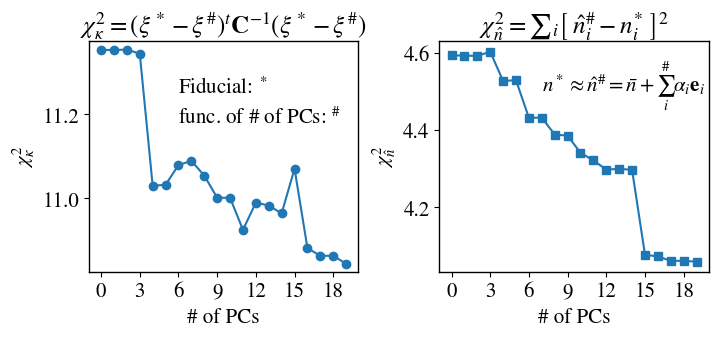

In [300]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False,figsize=(8, 3),
                        gridspec_kw={'wspace':0.3, 'hspace':0.1})

chi2_roman_cosmic_shear = -2*np.array(loglikes)
print('log(likes):   ',loglikes)
print('-2xlog(likes):',list(chi2_roman_cosmic_shear))

axes[0].plot(list(range(len(loglikes))),chi2_roman_cosmic_shear,marker='o')
axes[0].set_xticks(range(0,20 + 1, 3));
axes[0].set_ylim(np.min(chi2_roman_cosmic_shear)-.02,np.max(chi2_roman_cosmic_shear)+.02)
axes[0].set_xlabel('# of PCs')
axes[0].set_ylabel(r'$\chi^2_{\kappa}$');
axes[0].set_title(r'$\chi^2_{\kappa} = (\xi^*-\xi^\#)^t\mathbf{C}^{-1}(\xi^*-\xi^\#)$');
axes[0].annotate(r'Fiducial: ${}^*$',xy=(6,11.25));
axes[0].annotate(r'func. of # of PCs: ${}^\#$',xy=(6,11.18));

axes[1].plot(list(range(len(loglikes))),chi2_total,marker='s')
axes[1].set_xticks(range(0,20 + 1, 3));
axes[1].set_xlabel('# of PCs')
axes[1].set_ylabel(r'$\chi^2_\hat{n}$');
axes[1].set_title(r'$\chi^2_\hat{n} = \sum{}_i\left[~\hat{n}_i^\#-n_i^{*}~\right]^2$');
axes[1].annotate(r'$n^*\approx\hat{n}^\#=\bar{n}+\sum_i^\#\alpha_i\mathbf{e}_i$',xy=(7,4.5));

### Test 7 - $\alpha$'s distribution  
The PCs amplitudes $\alpha_i$'s are the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

In [13]:
# Here we need ndiff so we set use_r to 500 << 10^6
roman_obj = SURVEY('roman',use_r=500)
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()

Cn, ndiff = roman_obj.cov_of_ndiff()

eih_vecs, eigh_vals = roman_obj.pcs('eigh')

Total # of realizations r = 500
Normalizing nz for r:
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 

In [7]:
alphas = ndiff @ eih_vecs

alphas.shape
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]

chains = MCSamples(samples=alphas,names=names,labels=labels)

ValueError: matmul: Input operand 0 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

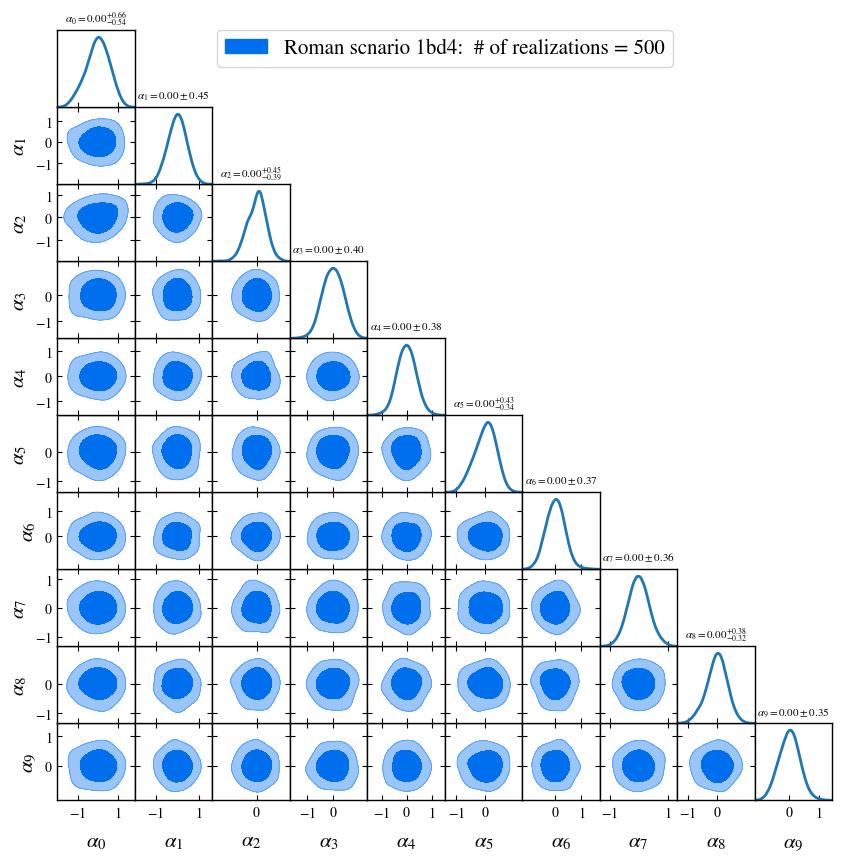

In [15]:
g = plots.get_subplot_plotter(subplot_size=1)
g.settings.title_limit_fontsize = 13
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.triangle_plot(chains,
                ["alpha%s" %i for i in range(10)],
                legend_labels=[f"Roman scnario 1bd4:  # of realizations = {roman_obj.use_r}"],
                filled=True,title_limit=1,
                line_args=[{"ls": "-", "color": "C0",'lw':2}])

## DES case

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{299}],[\text{PC}^1_{300},\text{PC}^1_{301},\cdots,\text{PC}^1_{598}],1\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{898},\cdots,\text{PC}^1_{1196}]\Big]$

In [16]:
des_obj = SURVEY('des')
Nz,Nt = des_obj.nz_params()
z,nz = des_obj.get_nzs()

Cn, ndiff = des_obj.cov_of_ndiff() # must call before pcs

eig_vecs, eig_vals = des_obj.pcs('eig')
eih_vecs, eigh_vals = des_obj.pcs('eigh')
svd_vecs, svd_vals = des_obj.pcs('svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = des_obj.pcs('sklearn')

<Figure size 350x250 with 0 Axes>

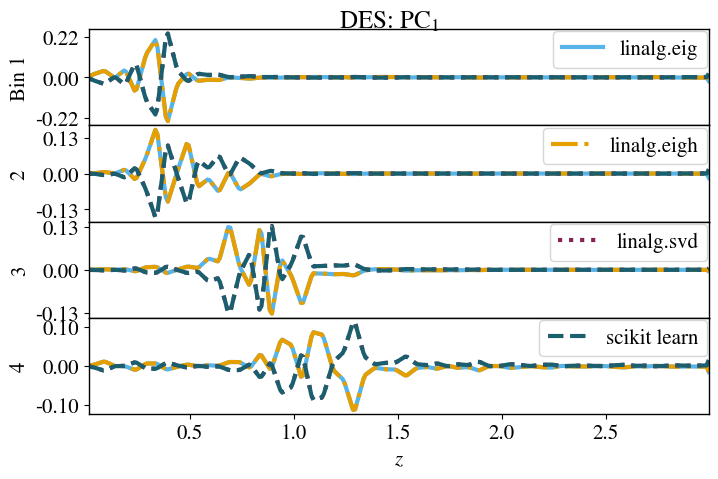

In [17]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.plot(z, eig_vecs[start:end, pci],c=colors[0],lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c=colors[1],lw=3, ls='-.', label='linalg.eigh' if k==1 else None)
    ax.plot(z, svd_vecs[start:end, pci],c=colors[2],lw=3, ls=':', label='linalg.svd' if k==2 else None)
    ax.plot(z, skl_vecs[start:end, pci],c=colors[3],lw=3, ls='--' , label='scikit learn' if k==3 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_{{{pci+1}}}$", y=0.92);

### Test 2 - Pick up the first three PCs and plot their slices across the tomographic bins

/tmp/ipykernel_3926373/3076853019.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

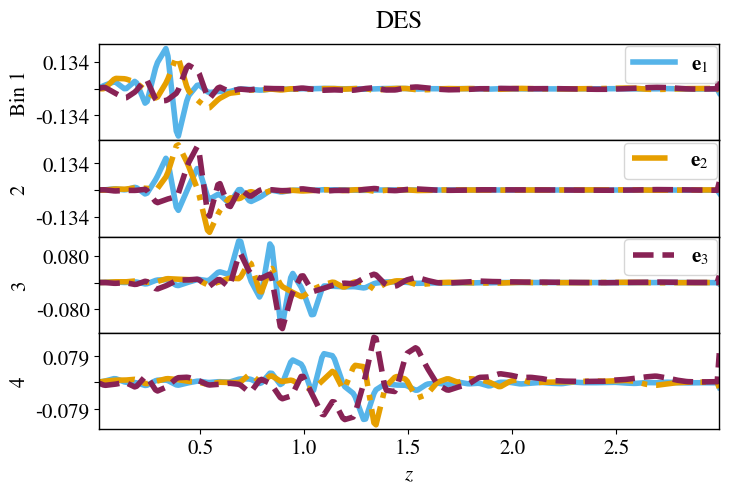

In [18]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})

pcis = [0,1,2]

colors=['#56B4E9',"#E69F00","#882255","#1b5f6f"]

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, -3))
formatter.set_scientific(True)
tick_label_formatter = FuncFormatter(lambda y, _: f"{y:.0f}") 

for k, ax in enumerate(axes):  # k = tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    e1 = eig_vecs[start:end, pcis[0]]
    e2 = eig_vecs[start:end, pcis[1]]
    e3 = eig_vecs[start:end, pcis[2]]

    max_y = np.max([np.max(e1), np.max(e2), np.max(e3)])
    min_y = np.min([np.min(e1), np.min(e2), np.min(e3)])
    d_y = (max_y - min_y) / 3.3
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_visible(k == 0)

    def format_ticks(y, _):
        if np.isclose(y, 0.0):
            return ''
        else:
            return f'{y:.3f}'
    ax.yaxis.set_major_formatter(FuncFormatter(format_ticks))

    ks = [0, 1, 2]
    ax.plot(z, e1, c=colors[0], lw=4, ls='-', label=r'$\mathbf{e}$'+rf'$_{{{pcis[0]+1}}}$' if k==ks[0] else None)
    ax.plot(z, e2, c=colors[1], lw=4, ls='-.', label=r'$\mathbf{e}$'+rf'$_{{{pcis[1]+1}}}$' if k==ks[1] else None)
    ax.plot(z, e3, c=colors[2], lw=4, ls='--', label=r'$\mathbf{e}$'+rf'$_{{{pcis[2]+1}}}$' if k==ks[2] else None)

    ax.set_ylabel(f'Bin {k+1}' if k == 0 else f'{k+1}')
    ax.legend(loc='upper right', borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES", y=0.95);

### Test 3 - Plot the eigenvalues
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The eigenvalues/singular values are the same.

Text(0.5, 0.98, 'DES')

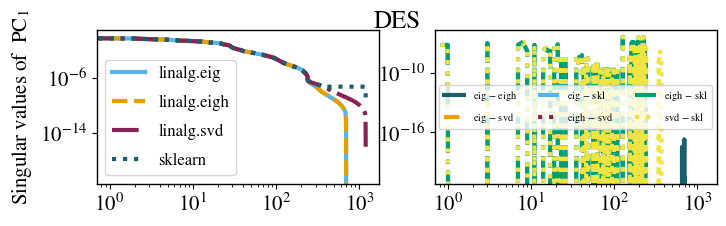

In [19]:
Ms = list(range(Nz*Nt))

fig, axes = plt.subplots(1, 2, figsize=(8, 2), sharex=True)

axes[0].plot(Ms,eig_vals ,c=colors[0],lw=3, ls='-' ,label='linalg.eig')
axes[0].plot(Ms,eigh_vals,c=colors[1],lw=3, ls='--',label='linalg.eigh')
axes[0].plot(Ms,svd_vals ,c=colors[2],lw=3, ls='-.',label='linalg.svd')
axes[0].plot(Ms,skl_vals ,c=colors[3],lw=3, ls=':' ,label='sklearn')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylabel(rf'Singular values of  PC$_1$')
axes[0].legend(loc='best',fontsize=12)

axes[1].loglog(Ms,eig_vals-eigh_vals,c=colors1[0],lw=3, ls='-' ,label=r'eig $-$ eigh')
axes[1].loglog(Ms,eig_vals-svd_vals, c=colors1[1],lw=3, ls='--',label=r'eig $-$ svd')
axes[1].loglog(Ms,eig_vals-skl_vals, c=colors1[2],lw=3, ls='-.',label=r'eig $-$ skl')

axes[1].loglog(Ms,eigh_vals-svd_vals,c=colors1[3],lw=3, ls=':' ,label=r'eigh $-$ svd')
axes[1].loglog(Ms,eigh_vals-skl_vals,c=colors1[4],lw=3, ls='-.',label=r'eigh $-$ skl')

axes[1].loglog(Ms,svd_vals-skl_vals, c=colors1[5],lw=3, ls=':',label=r'svd $-$ skl')
axes[1].legend(loc='center',fontsize=7.5,ncol=3)
fig.suptitle('DES')

### Test 4 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758).  
However, if we force $F=I$, then both methods possoes the same eigenvalue, while the eigenvector differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigenvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eigenvectors differ by a scaling factor of $\Lambda_n^{1/2}$:  
The decoding matrix (eq 19/20 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [20]:
D = np.identity(Cn.shape[0])

if not des_obj.isPD(D):
    print('fixing cov')
    D=des_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = des_obj.getModes(D,Cn,chisq_threshold=0);

/tmp/ipykernel_3926373/3877155883.py:205: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


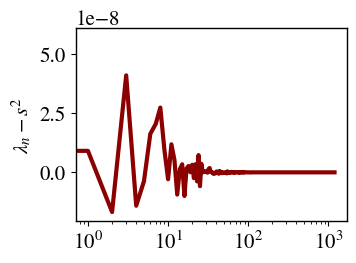

In [21]:
plt.plot(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.xscale('log')
plt.ylabel(r'$\lambda_n-s^2$');

/tmp/ipykernel_3926373/1309737692.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

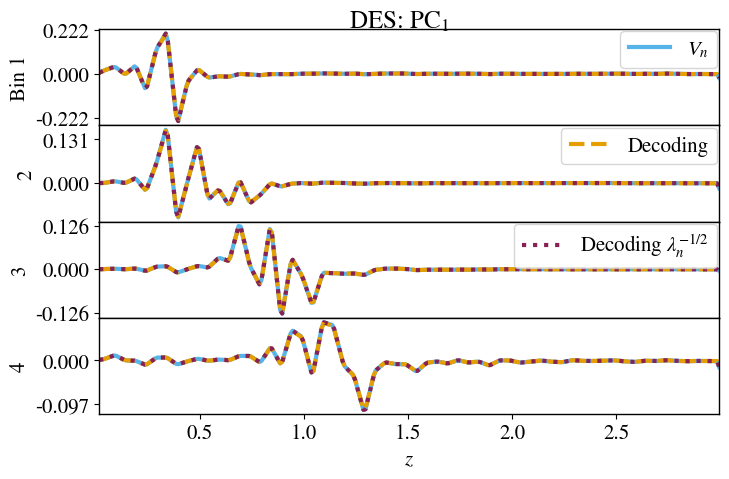

In [22]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix  = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 5),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

ks = [0,1,2]

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==ks[0] else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==ks[1] else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls=':', label=r'Decoding $\lambda_n^{-1/2}$' if k==ks[2] else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}')
    ax.legend(loc='upper right',borderaxespad=.1)

unused_legs = [x for x in range(Nt) if x not in ks]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$')
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_1$", y=0.92);

### Test 5 - PCs amplitudes distribution  
The amplitudes $\alpha_i$'s are the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

In [23]:
alphas = ndiff @ eih_vecs

alphas.shape
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]

chains = MCSamples(samples=alphas,names=names,labels=labels)

nEig:  1196
Removed no burn in


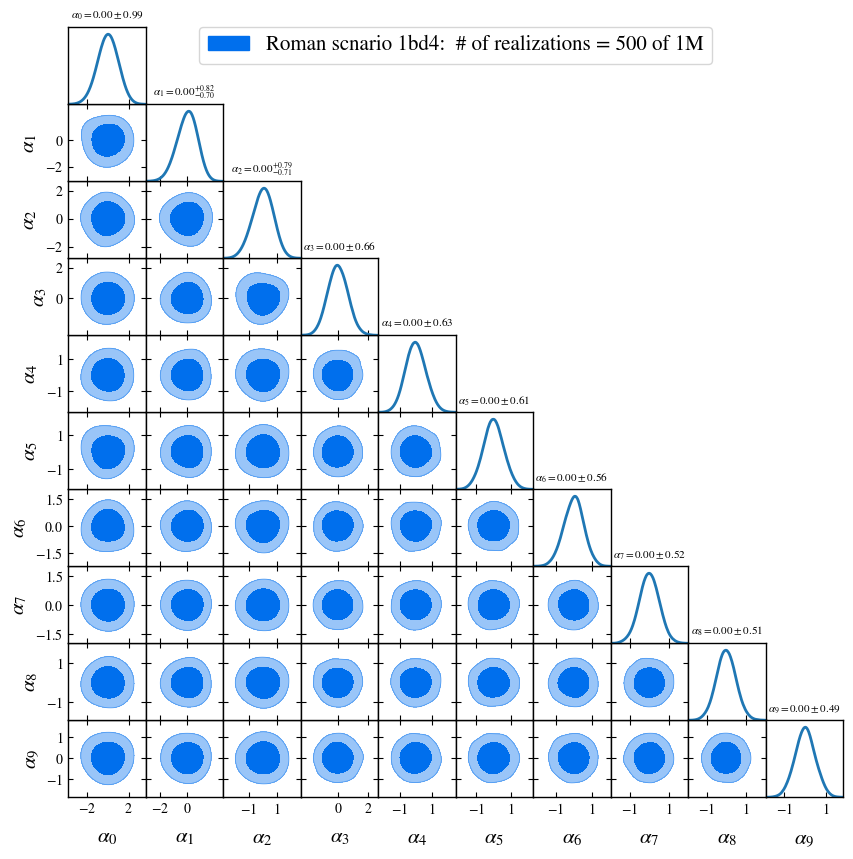

In [24]:
g = plots.get_subplot_plotter(subplot_size=1)
g.settings.title_limit_fontsize = 13
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.triangle_plot(chains,
                ["alpha%s" %i for i in range(10)],
                legend_labels=[f"Roman scnario 1bd4:  # of realizations = {r}"],
                filled=True,title_limit=1,
                line_args=[{"ls": "-", "color": "C0",'lw':2}])

# Lets check the function that forward the PCA model of $n(z)$ to CoCoA  
More specifically, to _cosmolike_prototype_interface.py.  
CoCoA needs nz in the form [z, nz_tomo_1, nz_tomo_2, ..., nz_tomo_n] where nz_tomo_i is the nz in the ith tomographic bin.  
The PCs, by construction, are obtained from the concatenation across the tomographic bins of the array nz-nbar    
The PCs are saved in a table with shape (len(PC), # PCs) = (len(z) * Ntomo, len(z) * Ntomo)  
The model: $n(z) = \bar{n}(z)+\alpha_1\cdot\mathbf{PC}_1+\alpha_2\cdot\mathbf{PC}_2+\cdots+\alpha_n\cdot\mathbf{PC}_n$  

In [25]:
nbar_fake = np.array([[1,2,3,4],  [5,6,7,8],   [9,10,11,12]]).T  # 3 tomo bins, 4 redshift bins as provided to cocoa
pcs_fake = np.array([[1,2,3,4,     5,6,7,8,     9,10,11,12],     # PC_1
                     [13,14,15,16, 17,18,19,20, 21,22,23,24]]).T # PC_2

npcs = 2 
U = pcs_fake
params_values = {"fake_alpha_1":2,"fake_alpha_2":1} # fake params from cobaya
alphas = np.array([params_values.get("fake_alpha_"+str(i+1)) for i in range(npcs)])

print(f"{'PC_1':>5} {'PC_2':>5} {'':>1} {'<nz>_1':>7}{'<nz>_2':>7}{'<nz>_3':>7}")

# Max rows needed: max(12 for PCs, 4 for nbar_fake)
max_rows = max(len(pcs_fake), nbar_fake.shape[0])

for i in range(max_rows):
    pc1 = pcs_fake[i,0] if i < len(pcs_fake) else ''
    pc2 = pcs_fake[i,1] if i < len(pcs_fake) else ''
    nz1 = nbar_fake[i,0] if i < nbar_fake.shape[0] else ''
    nz2 = nbar_fake[i,1] if i < nbar_fake.shape[0] else ''
    nz3 = nbar_fake[i,2] if i < nbar_fake.shape[0] else ''
    print(f"{pc1:5} {pc2:5} {nz1:6} {nz2:6} {nz3:6}")

 PC_1  PC_2    <nz>_1 <nz>_2 <nz>_3
    1    13      1      5      9
    2    14      2      6     10
    3    15      3      7     11
    4    16      4      8     12
    5    17                     
    6    18                     
    7    19                     
    8    20                     
    9    21                     
   10    22                     
   11    23                     
   12    24                     


In [26]:
alphas_x_U = (alphas * U)
correction = (alphas * U).sum(axis=1)

print(f"{'α1·PC1':>5} {'α2·PC2':>5}  {'':>2} {'α1·PC1 + α2·PC2':>9}")

for i in range(len(alphas_x_U)):
    α1_x_pc1 = alphas_x_U[i,0] 
    α2_x_pc2 = alphas_x_U[i,1] 
    corr = correction[i] 
    print(f"{α1_x_pc1:5} {α2_x_pc2:5} {corr:15}")

α1·PC1 α2·PC2     α1·PC1 + α2·PC2
    2    13              15
    4    14              18
    6    15              21
    8    16              24
   10    17              27
   12    18              30
   14    19              33
   16    20              36
   18    21              39
   20    22              42
   22    23              45
   24    24              48


In [27]:
s = nbar_fake[:,:].shape # in the code we do self.nbar[:,1:].shape to not cout the redshift column, here isn't necessary
print(s)

(4, 3)


In [28]:
nz_model = nbar_fake[:,:].T.flatten() + correction # in the code we do self.nbar[:,1:].T.flatten() to not count the redshift column, here isn't necessary
nz_model_2 = nz_model.reshape(s[::-1]).T
print('STEP 1: <nbar>:\n',nbar_fake,'\n')
print('STEP 2: <nbar> flattened:',nbar_fake[:,:].T.flatten(),'\n')
print('STEP 3: correction:', correction,'\n')
print('STEP 4: <nbar> flattened + correction:',nz_model,'\n')
print('STEP 5: restore nz in CoCoA table-like format:\n',nz_model_2)

STEP 1: <nbar>:
 [[ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]
 [ 4  8 12]] 

STEP 2: <nbar> flattened: [ 1  2  3  4  5  6  7  8  9 10 11 12] 

STEP 3: correction: [15 18 21 24 27 30 33 36 39 42 45 48] 

STEP 4: <nbar> flattened + correction: [16 20 24 28 32 36 40 44 48 52 56 60] 

STEP 5: restore nz in CoCoA table-like format:
 [[16 32 48]
 [20 36 52]
 [24 40 56]
 [28 44 60]]


# Working in progress - ignore codes from this point

In [ ]:
n_pcs = 2
n_bins = 3
n_z = 4

pcs_reshaped = pcs_fake.reshape(n_pcs, n_bins, n_z)
pcs_reshaped = pcs_reshaped.transpose(0,2,1)  # (n_pcs, n_z, n_bins)
print(pcs_fake)
print(pcs_reshaped)
alphas = np.array([params_values.get(f"fake_alpha_{i+1}") for i in range(n_pcs)])
print(alphas)
pc_sum = np.sum([alpha * pcs_reshaped[i] for i, alpha in enumerate(alphas)], axis=0)
nz_modified = nbar_fake + pc_sum
print(nz_modified)
print(nz_model_2)

In [13]:
def forward_pca(nz_fid,params_values,survey,photoz_pc_file,npc):
    
    if npc == 0:
        return nz_fid

    elif npc > 0:
        U = photoz_pc_file[:,:npc] # Here is not a file, but in CoCoA is. We keep the notation.
        alphas_vals = np.array([params_values.get(survey+"_alpha_"+str(i+1)) for i in range(npc)])
        
        correction = (alphas_vals * U).sum(axis=1)

        s = nz_fid[:,1:].shape # (46,9)
        z = nz_fid[:,0]

        nz_model = nz_fid[:,1:].T.flatten() + correction # |nz_model| ~ 1 for npc << 414 and |alpha| ~< 1.
        nz_model = nz_model.reshape(s[::-1]).T
        nz_model = np.column_stack((z,nz_model))

        return nz_model

# def pca(self, params_values):
#     if self.npcs_nz > 0:
#         #TODO: optimization: if U.shape = nz.shpae, reshape nz will not be necessary
#         alphas = np.array([params_values.get("roman_alpha_"+str(i+1)) for i in range(self.npcs_nz)])
#         correction = (alphas * self.U).sum(axis=1)

#         s = self.nbar[:,1:].shape
#         z = self.nbar[:,0]

#         nz_model = self.nbar[:,1:].T.flatten() + correction
#         nz_model = nz_model.reshape(s[::-1]).T
#         np.savetxt("nz_model_1.nz",nz_model)
#         nz_model = np.column_stack((z,nz_model))
#         return nz_model
#     else:
#         return None

In [ ]:
# Lets assume the amplitudes are drawn a normal distribution
seed = 40 # If the seed is turned off, the plot below will be different.
rng = np.random.default_rng(seed)
dist = norm(loc=0, scale=1)
alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)

alphas_r_dict = {f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)}

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) #(46,9) -> (46,10)

plt.figure()
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True,figsize=(12, 2.4),
                        gridspec_kw={'wspace':0.01, 'hspace':0.0})

for npc in range(ncols):
    for k in range(Nt):
        nz_mod = forward_pca(nz_fid,alphas_r_dict,'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
        axes[npc].plot(z,nz_fid[:,k+1],'C0', label='nz_fid' if npc==0 and k==0 else None)
        axes[npc].plot(z,nz_mod[:,k+1],ls=':',c='k', label='nz_mod' if npc==1 and k==0 else None)
        if npc == 0:
            axes[npc].set_title(f'No PC')
        else:    
            axes[npc].set_title(rf'{npc} PC, $\alpha_{{{npc}}}$: {alphas_r_dict[f"roman_alpha_{npc+1}"]:.2f}')
        axes[npc].set_xlabel(r'$z$')
        axes[0].set_ylabel(r'$n(z)$')
        axes[npc].legend(loc='best')

$\hat{\mathbf{n}}(z)=\bar{\mathbf{n}}(z) +\sum_{i=1}^M\alpha_i\mathbf{e}_i(z)$

In [15]:
alphas_r_dict2 = []
for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

In [16]:
seeds, alphas_r_dict, dist = range(r), [], norm(loc=0, scale=1) # 1 seed for each realization r
alphas_r_dict2 = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)
    alphas_r_dict.append({f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)})
alphas_r_dict = np.stack(alphas_r_dict) # (r,)

for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) # (46,9) -> (46,10)
npc = 3
nzr_mod = []
for ri in range(r):
    x = forward_pca(nz_fid,alphas_r_dict2[ri],'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
    nzr_mod.append(x[:,1:])
nzr_mod = np.stack(nzr_mod) # (r, 46, 10)
nzr_mod_new = nzr_mod[:,:,:1].transpose(0, 2, 1) #(r, 1, 46)

In [ ]:
def distribution_violinplot():
    plt.figure(figsize=(10, 4))
    
    nzs = f'{path}roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5'
    nzs = h5py.File(nzs,'r') 
    zbins = np.array(nzs['zbinsc'])
    row=[]
    for j in range(r):
        normalized = nz[f'bin0'][j] / np.trapz(y=nz[f'bin0'][j], x=z)
        row.append(normalized)
    nzs = np.stack(row)
    nzs = np.expand_dims(nzs, axis=1)
    # nzs = np.stack([nzs[f'bin0'][:100,:]], axis=1) #(r, 1, 46)
    v1=plt.violinplot(nzs[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v1['bodies']:
        body.set_facecolor('#FDB863')
        body.set_alpha(0.8)

    v2=plt.violinplot(nzr_mod_new[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v2['bodies']:
        body.set_facecolor('C0')
        body.set_alpha(0.5)
    plt.xlabel(r'$\mathrm{z}$')
    plt.ylabel(r'$\text{Distribution of } n(z)$')
    plt.title('Tomographic bin: 1')
    plt.tight_layout()
    return None
distribution_violinplot()

## Weighted PCA

In [51]:
# Process all bins, independently
nz_mean_lens = []
nz_lens = []
nzhat_lens = []
u_lens = []
U_lens = []
dchisq_lens = []

path='/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'
sc = 'sc1b_d6'
ff = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')

def dchisq_func(method='A'):
    for bin in range(6):
        chisq_threshold = 0.00
        nSamp = 5000

        nz = np.array(ff['bin'+str(bin)][::nSamp])
        z = np.array(ff['zbinsc'])
        
        nz = nz / np.trapz(nz,x=z,axis=1)[:,np.newaxis]
        # print('sum_nz:', np.sum(nz[0]))

        nz_mean = np.mean(nz,axis=0)
        nz = nz - nz_mean
        Cn = np.einsum('ij,ik->jk',nz,nz) / (nz.shape[0]-1)
        
        if method == 'A':
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'B':
            D_lens = np.genfromtxt(f'{path}/results/fisher_matrix/roman_sc1bd4/fisher.txt')
            # print(D.shape,Cn.shape)
            D = D_lens[bin*Nz:(bin+1)*Nz, bin*Nz:(bin+1)*Nz].copy()
            X,U,dchisq,resids = getModes(D, Cn, chisq_threshold=chisq_threshold)
        S=dchisq
        # Sort SV's and throw away unwanted ones
        s = S.copy()
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
     
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        dchisq = s[keep]
        dchisq_lens.append(dchisq.copy())
    return dchisq_lens

In [ ]:
# Plot Chisq shifts
dchisq_lens = dchisq_func(method='B')

fig,ax = plt.subplots(3,2,figsize=(8,6), sharex=True)
for bin in range(6):
    ix = bin//3
    iy = bin%3
    # h1 = ax[iy,ix].plot(dchisq_lens[bin],label='dz=0.01')
    h1 = ax[iy,ix].plot(dchisq_lens[bin])

    ax[iy,ix].text(0.95,0.95,'Bin {:d}'.format(bin+1),transform=ax[iy,ix].transAxes,ha='right',va='top')
    ax[iy,ix].set_yscale('log')
    if iy==2:
        ax[iy,ix].set_xlabel(r'$N_{\rm modes}$')
    if ix==0:
        ax[iy,ix].set_ylabel(r'$ \chi^2$')
ax[0,1].legend()
#fig.suptitle(r'Histograms of $\Delta \chi^2$ for SOMPZ+WZ samples')
plt.tight_layout()